In [13]:
#source TFAvenv/bin/activate (launching and exiting the virtual environment containing the required modules, stored in the working directory)
#TFAvenv/bin/python your_script.py - for running a script in the virtual environment
#source deactivate

#import all the libraries needed
from import_dep import *
import importlib

# import my functions stored in the file 'functions' which can then be called with functions.function_name()
from SMU import SMU
import SMU_functions
importlib.reload(SMU_functions)  # Force reload to get updated function signatures with auto-scaling
from SMU_functions import plot_IV, plot_CV, plot_resistance, plot_permittivity

# import custom plot style and colorbar functions
import plot_style
importlib.reload(plot_style)  # Force reload to get updated markersize parameter
from plot_style import set_plot_style

# Define the path to the root directory containing all the Keithley data
root_SMU = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/'
output_SMU = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/DR012/Output'
root_SMU_SM04 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/SM04/Data'
output_SMU_SM04 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/SM04/Output'

root_SMU_SM06 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/SM06/Data'
output_SM06 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/SM06/Output'


root_MFS097 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/IS/MFS097/'
output_MFS097 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/IS/MFS097/Output'

root_JT147 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/JT147/Data'
output_JT147 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/JT147/Output'





### Plotting and Output Variables 
export_data = False # set to True to export the data to a powerpoint presentation and as svg files and export to path_out
fig_format = 'svg' # format of the figure to be saved

powerpoint_string = 'H03C5' # string to be added to the powerpoint file name

plot_transparency = True # set to True to make the data plots transparent

# Custom plot style settings with small markersize
# This will now work because plot_style.py respects the markersize parameter
fig_size = set_plot_style(export_data=export_data, use_tex=True, markersize=0.1)

# Alternative: You can also pass markersize directly to each plot function
# plot_IV(..., markersize=0.1)
# plot_CV(..., markersize=0.1) 
# plot_resistance(..., markersize=0.1)


In [11]:
# Test the SMU class by loading data
print("Testing SMU class...")

# Create SMU object
smu_DR012 = SMU(root_SMU)
smu_SM04 = SMU(root_SMU_SM04)
smu_SM06 = SMU(root_SMU_SM06)

smu_H03C5 = SMU(root_SMU + 'H03C5/Data/IVoop')
output_H03C5 = root_SMU + 'H03C5/Output'

smu_MFS097 = SMU(root_MFS097)

smu_JT147 = SMU(root_SMU + 'JT147/Data')
output_JT147 = root_SMU + 'JT147/Output'


# # Display basic information
# print(f"\nSMU object: {smu_SM04}")
# print(f"CV run numbers: {smu_SM04.cv_run_nums[:10]}...")  # Show first 10
# print(f"IV run numbers: {smu_SM04.iv_run_nums[:10]}...")  # Show first 10
# print(f"\nSMU object: {smu_SM06}")
# print(f"CV run numbers: {smu_SM06.cv_run_nums[:10]}...")  # Show first 10
# print(f"IV run numbers: {smu_SM06.iv_run_nums[:10]}...")  # Show first 10

# # Show sample CV data
# if smu_DR012.cv_data:
#     print(f"\nSample CV data (first file):")
#     print(smu_DR012.cv_data[0].head())

# # Show sample IV data  
# if smu_SM04.iv_data:
#     print(f"\nSample IV data (first file):")
#     print(smu_SR04.iv_data[0].head())
    
# if smu_SM06.iv_data:
#     print(f"\nSample IV data (first file):")
#     print(smu_SM06.iv_data[0].head())

Testing SMU class...
Error: No .xlsx files were found.
Found 103 Excel files
Loaded 0 CV, 1 IV, 102 IV3T, 0 PUND, 0 Custom files
Found 35 Excel files
Loaded 0 CV, 2 IV, 33 IV3T, 0 PUND, 0 Custom files
Found 3 Excel files
Loaded 0 CV, 3 IV, 0 IV3T, 0 PUND, 0 Custom files
Found 1 Excel files
  CV auto-assigned run 0 → cv-cap_MFS097.xlsx [1kHz_-2V to +2V]
  CV auto-assigned run 1 → cv-cap_MFS097.xlsx [100kHz_-2V to +2V]
Loaded 2 CV, 0 IV, 0 IV3T, 0 PUND, 0 Custom files
Found 5 Excel files
Loaded 0 CV, 2 IV, 1 IV3T, 1 PUND, 1 Custom files


# IV Plotting

## Linear (Ohmic)

In Ohmic conduction, electrons move through the film as free carriers drifting under the applied electric field, scattering off lattice vibrations and defects — exactly as in a bulk resistor. The density of thermally generated free carriers in the material is large enough that the injected charge from the electrodes does not significantly perturb the internal field, so current scales linearly with voltage.

**Current–voltage relation:**

$$I = \frac{V}{R} = \frac{q n \mu A}{d}\, V$$

where $q$ is the electronic charge, $n$ the free carrier density, $\mu$ the mobility, $A$ the device area, and $d$ the film thickness.

**Plot:** $I$ vs $V$

**What to look for:**
- A straight line through the origin confirms Ohmic conduction.
- The slope gives the resistance $R$ (or conductance $G = 1/R$).
- Deviations from linearity at higher voltages indicate the onset of a different conduction mechanism (e.g. SCLC, Schottky).

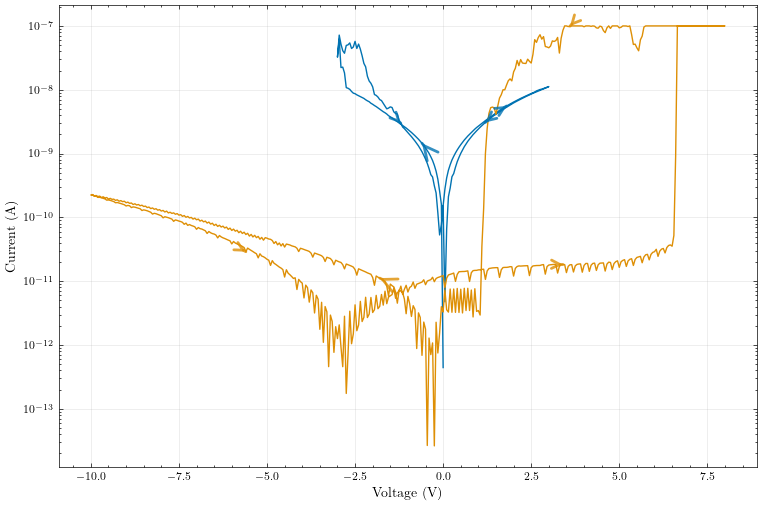

In [16]:
## IV Analysis with Direction Arrows

# Select specific runs for analysis using the built-in methods

#selected_iv_runs = [ 398, 399, 401, 402] 
#selected_iv_runs = [389, 390,392, 404, 398]
selected_iv_runs = [10]
fig_format = 'svg'
export_data = False # set to True to export the data to a powerpoint presentation and as svg files and export to path_out
fig_iv = plot_IV(smu_data = [smu_SM06], 
                       #run_nums=[[10,30]], 
                       plot_mode='log', #'linear', 'log', 'SCLC', 'schottky', 'PF', 'FN', 'TAT'
                       plot_arrows=True,
                       fig_format = fig_format,
                       plot_key=False,
                        #y_lim=[1e-12, 1e-10],
                        #line_width =0.6,
                        #markersize=0.9,
                       export_data=export_data, output_SMU=output_SM06,
                       plot_transparency=plot_transparency)

    
# fig_R = plot_resistance([smu_SM06], run_nums=selected_iv_runs, 
#                        log_plot=True,
#                        line_width =0.6,
#                         markersize=0.9,
#                        export_data=export_data, plot_arrows = True, output_SMU=output_SMU_SM06,
#                        plot_transparency=plot_transparency)

## Space-Charge Limited Current (SCLC)

At higher voltages the electrodes inject more carriers into the film than are thermally present, and this excess charge builds up a space-charge region that redistributes the internal electric field. Electrons still drift classically through the conduction band, but their own accumulated charge opposes further injection and limits the current. If the film contains trap states (e.g. oxygen vacancies), injected carriers initially fill these traps and are immobilised; once the traps are full the current rises steeply before returning to the space-charge-limited $V^2$ dependence.

**Current–voltage relation (Mott–Gurney law with traps):**

$$I = \frac{9}{8}\, \varepsilon_0 \varepsilon_r \mu \theta \frac{A}{d^3}\, V^\alpha$$

where $\varepsilon_0 \varepsilon_r$ is the permittivity, $\mu$ the mobility, $\theta$ the trap-filling factor, $A$ the area, and $d$ the film thickness. The exponent $\alpha$ identifies the transport regime.

**Plot:** $\log_{10}|I|$ vs $\log_{10}|V|$

**What to look for — slope $\alpha$ of the straight-line regions:**
- $\alpha \approx 1$: **Ohmic regime** — thermally generated carriers dominate, $I \propto V$.
- $\alpha \approx 2$: **Child's law (trap-free SCLC)** — injected space charge dominates, $I \propto V^2$.
- $\alpha \gg 2$: **Trap-filled limit (TFL)** — steep rise as traps fill; the voltage at the transition ($V_\text{TFL}$) gives the trap density $N_t$.
- $\alpha \approx 2$ (at higher $V$): **Trap-saturated SCLC** — all traps filled, returns to trap-free $V^2$ behaviour.

Distinct straight-line segments with these slopes are the hallmark of SCLC in oxide thin films and memristive devices.

/Users/horatiocox/Desktop/Thin_Film_Analysis/SMU_functions.py:624: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


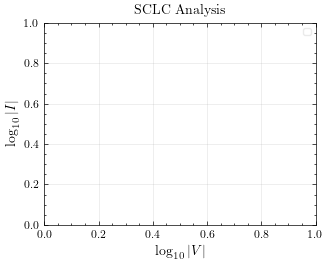

In [9]:
# Select specific runs for analysis using the built-in methods
selected_iv_runs = [393, 394, 395, 396, 397, 398]

fig_iv = plot_IV([smu_DR012], run_nums=selected_iv_runs, 
                       plot_mode='SCLC', #'linear', 'SCLC', 'schottky', 'PF', 'FN', 'TAT'
                       plot_arrows=True,
                        #y_lim=[-0.1, 0.1],
                        line_width =0.6,
                        markersize=0.9,
                       export_data=export_data, output_SMU=output_SMU,
                       plot_transparency=plot_transparency)


## Schottky / Thermionic Emission

At the metal–insulator interface there is an energy barrier $\phi_B$ that electrons in the metal must overcome to enter the oxide conduction band. In Schottky (thermionic) emission, electrons gain enough thermal energy from the lattice to pass *over* the top of this barrier — they are not tunnelling through it. The applied electric field lowers the effective barrier height via image-charge effects (Schottky barrier lowering), so the fraction of electrons with sufficient energy increases exponentially with $\sqrt{V}$. Because the rate-limiting step is at the contact, this is an interface-limited mechanism.

**Current–voltage relation:**

$$I = A^{*} T^2 \exp\!\left[ -\frac{q\!\left(\phi_B - \sqrt{\dfrac{qV}{4\pi \varepsilon_0 \varepsilon_r d}}\right)}{k_B T} \right]$$

where $A^{*}$ is the effective Richardson constant, $\phi_B$ the barrier height, $\varepsilon_0 \varepsilon_r$ the permittivity, $d$ the film thickness, and $k_B T$ the thermal energy.

**Linearised form:**

$$\ln|I| = \ln I_0 + \frac{q}{k_B T}\sqrt{\frac{q}{4\pi \varepsilon_0 \varepsilon_r d}}\;\sqrt{V}$$

**Plot:** $\ln|I|$ vs $\sqrt{|V|}$

**What to look for:**
- A **straight line** confirms thermionic (Schottky) emission over the metal–insulator interface barrier.
- The **slope** gives $\beta_S = \dfrac{q}{k_B T}\sqrt{\dfrac{q}{4\pi \varepsilon_0 \varepsilon_r d}}$, from which the dynamic (optical) permittivity $\varepsilon_r$ can be extracted.
- The **intercept** $\ln I_0$ gives the zero-field barrier height $\phi_B$.
- This is an **interface-limited** mechanism — the barrier is at the electrode–oxide contact.

/Users/horatiocox/Desktop/Thin_Film_Analysis/SMU_functions.py:624: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


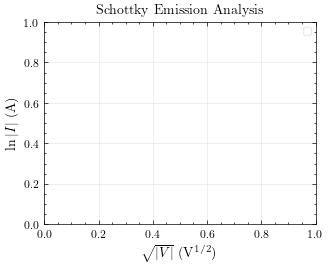

In [10]:
# Select specific runs for analysis using the built-in methods
selected_iv_runs = [393, 394, 395, 396, 397, 398]

fig_iv = plot_IV([smu_DR012], run_nums=selected_iv_runs, 
                       plot_mode='schottky', #'linear', 'SCLC', 'schottky', 'PF', 'FN', 'TAT'
                       plot_arrows=True,
                        #y_lim=[-0.1, 0.1],
                        line_width =0.6,
                        markersize=0.9,
                       export_data=export_data, output_SMU=output_SMU,
                       plot_transparency=plot_transparency)


## Poole–Frenkel Emission

In Poole–Frenkel emission the current is limited not by the electrode interface but by trap states distributed throughout the bulk of the film. Electrons are localised in Coulombic potential wells around charged defects (e.g. oxygen vacancies). The applied electric field tilts these potential wells, lowering the barrier on the field-facing side and allowing electrons to be thermally excited out of the traps and into the conduction band, where they drift until they are recaptured at the next trap. This "hop-and-release" process through the bulk gives PF its characteristic $\sqrt{V}$ field-lowering — similar to Schottky emission, but with twice the coefficient because the carrier sits *inside* the Coulombic well rather than at an image-charge boundary.

**Current–voltage relation:**

$$I = \frac{q \mu N_c A}{d}\, V \exp\!\left[ -\frac{q\!\left(\phi_T - \sqrt{\dfrac{qV}{\pi \varepsilon_0 \varepsilon_r d}}\right)}{k_B T} \right]$$

where $\phi_T$ is the trap depth, $\mu$ the mobility, $N_c$ the effective density of states, and the other symbols have their usual meaning.

**Linearised form:**

$$\ln\!\left(\frac{|I|}{|V|}\right) = C + \frac{q}{k_B T}\sqrt{\frac{q}{\pi \varepsilon_0 \varepsilon_r d}}\;\sqrt{V}$$

**Plot:** $\ln(|I|/|V|)$ vs $\sqrt{|V|}$

**What to look for:**
- A **straight line** confirms Poole–Frenkel emission: field-enhanced thermal detrapping from Coulombic trap centres in the bulk.
- The PF slope $\beta_{PF} = 2\,\beta_S$ (twice the Schottky slope). This factor-of-two difference is the key test to **distinguish PF (bulk) from Schottky (interface)** emission.
- The extracted $\varepsilon_r$ should be physically reasonable for the oxide (typically 4–25 for most transition-metal oxides).
- This is a **bulk-limited** mechanism — conduction is controlled by traps within the film, not the electrode interface.

/Users/horatiocox/Desktop/Thin_Film_Analysis/SMU_functions.py:624: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


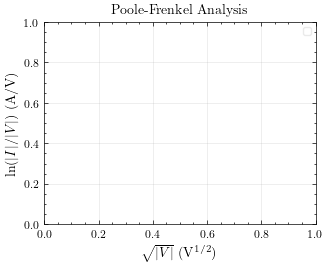

In [11]:
# Select specific runs for analysis using the built-in methods
selected_iv_runs = [393, 394, 395, 396, 397, 398]

fig_iv = plot_IV([smu_DR012], run_nums=selected_iv_runs, 
                       plot_mode='PF', #'linear', 'SCLC', 'schottky', 'PF', 'FN', 'TAT'
                       plot_arrows=True,
                        #y_lim=[-0.1, 0.1],
                        line_width =0.6,
                        markersize=0.9,
                       export_data=export_data, output_SMU=output_SMU,
                       plot_transparency=plot_transparency)


## Fowler–Nordheim Tunnelling

In Fowler–Nordheim tunnelling, electrons do not have enough thermal energy to pass over the barrier — instead they quantum-mechanically tunnel *through* it. At high electric fields the barrier becomes thin enough (triangular in profile) that the electron wavefunction has a significant probability of penetrating to the other side. The tunnelling probability depends exponentially on both the barrier height and the barrier width (which is inversely proportional to the field), so the current rises very steeply with voltage. Because tunnelling is a quantum-mechanical process, it is essentially temperature-independent.

**Current–voltage relation:**

$$I = \frac{q^3 A}{8\pi h \phi_B d^2}\, V^2 \exp\!\left[ -\frac{8\pi \sqrt{2m^{*}}\;\phi_B^{3/2}\, d}{3qhV} \right]$$

where $\phi_B$ is the barrier height, $m^{*}$ the effective tunnelling mass, $h$ Planck's constant, and $d$ the film thickness.

**Linearised form:**

$$\ln\!\left(\frac{|I|}{V^2}\right) = C - \frac{8\pi \sqrt{2m^{*}}\;\phi_B^{3/2}\, d}{3qh}\;\frac{1}{V}$$

**Plot:** $\ln(|I|/V^2)$ vs $1/|V|$

**What to look for:**
- A **straight line with negative slope** confirms Fowler–Nordheim (FN) quantum-mechanical tunnelling through a triangular barrier at high electric fields.
- The **slope** gives $\phi_B^{3/2}$ (if $d$ and $m^{*}$ are known), yielding the barrier height.
- FN tunnelling is expected only at **high fields** ($E \gtrsim$ a few MV/cm); at lower fields the data will deviate from linearity.
- FN is **temperature-independent** — if the slope changes significantly with temperature, consider trap-assisted tunnelling (TAT) instead.

/Users/horatiocox/Desktop/Thin_Film_Analysis/SMU_functions.py:624: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


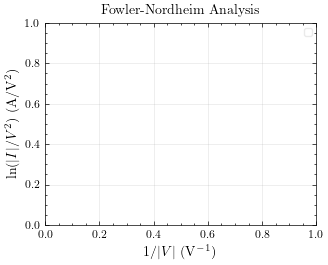

In [12]:
# Select specific runs for analysis using the built-in methods
selected_iv_runs = [393, 394, 395, 396, 397, 398]

fig_iv = plot_IV([smu_DR012], run_nums=selected_iv_runs, 
                       plot_mode='FN', #'linear', 'SCLC', 'schottky', 'PF', 'FN', 'TAT'
                       plot_arrows=True,
                        #y_lim=[-0.1, 0.1],
                        line_width =0.6,
                        markersize=0.9,
                       export_data=export_data, output_SMU=output_SMU,
                       plot_transparency=plot_transparency)


## Trap-Assisted Tunnelling (TAT)

Rather than tunnelling through the full width of the barrier in one step (as in FN), electrons tunnel via intermediate trap states — typically oxygen vacancies — that act as stepping stones through the insulator. An electron tunnels from the electrode (or a filled trap) into a nearby empty trap, relaxes into that localised state, and then tunnels onward to the next trap or to the opposite electrode. Each individual tunnelling step is much shorter than the full film thickness, so TAT can carry significant current at lower fields than pure FN tunnelling requires. In VCM memristors, the oxygen-vacancy filament provides a dense chain of these trap sites, making TAT the dominant conduction mechanism in the high-resistance state.

**Current–voltage relation:**

$$I \propto V^2 \exp\!\left[ -\frac{8\pi \sqrt{2m^{*}}\;\phi_T^{3/2}\, d_\text{trap}}{3qhV} \right]$$

where $\phi_T$ is the **trap depth** (not the full barrier height) and $d_\text{trap}$ is the inter-trap distance (not the full film thickness).

**Linearised form (same axes as FN):**

$$\ln\!\left(\frac{|I|}{V^2}\right) = C - \frac{8\pi \sqrt{2m^{*}}\;\phi_T^{3/2}\, d_\text{trap}}{3qh}\;\frac{1}{V}$$

**Plot:** $\ln(|I|/V^2)$ vs $1/|V|$

**What to look for:**
- A **straight line with negative slope** — same plot format as FN, but the extracted parameters differ.
- The extracted barrier is the **trap depth** $\phi_T$ (typically 0.1–1 eV), which is significantly **lower** than the full electrode barrier $\phi_B$ extracted from FN.
- TAT shows a **weak but measurable temperature dependence** (unlike pure FN), because thermally-activated capture/emission at trap sites is involved.
- TAT dominates at **moderate fields** in defect-rich films, while FN requires higher fields.
- Particularly important for **VCM memristors**: oxygen-vacancy filaments provide a chain of trap states enabling sequential trap-assisted tunnelling in the high-resistance state (HRS). The conductive filament geometry means $d_\text{trap} \ll d$.

/Users/horatiocox/Desktop/Thin_Film_Analysis/SMU_functions.py:624: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


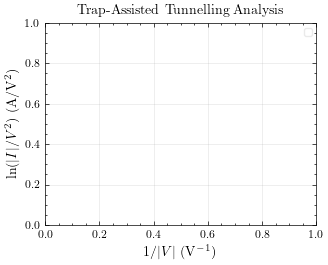

In [13]:
# Select specific runs for analysis using the built-in methods
selected_iv_runs = [393, 394, 395, 396, 397, 398]

fig_iv = plot_IV([smu_DR012], run_nums=selected_iv_runs, 
                       plot_mode='TAT', #'linear', 'SCLC', 'schottky', 'PF', 'FN', 'TAT'
                       plot_arrows=True,
                        #y_lim=[-0.1, 0.1],
                        line_width =0.6,
                        markersize=0.9,
                       export_data=export_data, output_SMU=output_SMU,
                       plot_transparency=plot_transparency)


# CV Plotting

/Users/horatiocox/Desktop/Thin_Film_Analysis/SMU_functions.py:750: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


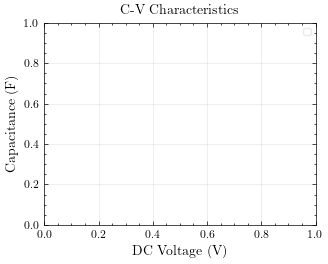


=== Testing Resistance Plot with Arrows ===


In [14]:
## CV Analysis
selected_cv_runs = [1, 10, 11] 

# Use get_cv_data and get_iv_data methods for clean data extraction
cv_data, cv_labels = smu_DR012.get_cv_data(run_nums=selected_cv_runs)

# Plot using the extracted data
fig_cv = plot_CV([smu_DR012], run_nums=selected_cv_runs, log_plot=False,
                 export_data=export_data, output_SMU=output_SMU,
                 plot_transparency=plot_transparency)

## Resistance Analysis with Arrows
print("\n=== Testing Resistance Plot with Arrows ===")
selected_resistance_runs = [1, 11]  # Fewer runs for clearer visualization


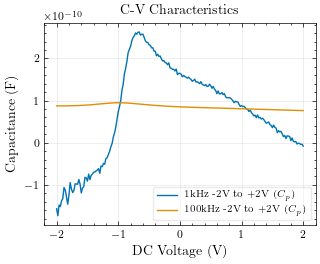

In [15]:
## CV Analysis - MFS097 (1 kHz and 100 kHz)

# Plot all CV runs from MFS097 (both frequency sheets) on the same axes
fig_cv_mfs097 = plot_CV([smu_MFS097], 
                        log_plot=False,
                        export_data=export_data, output_SMU=output_MFS097,
                        fig_name='MFS097',
                        plot_transparency=plot_transparency)


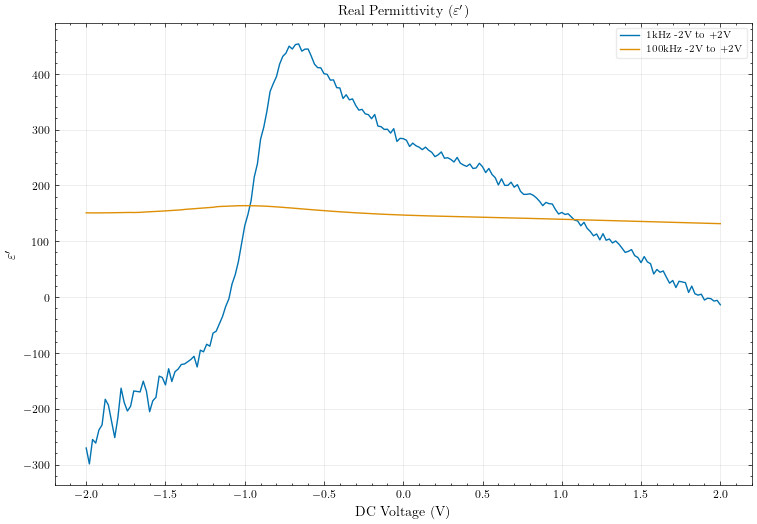

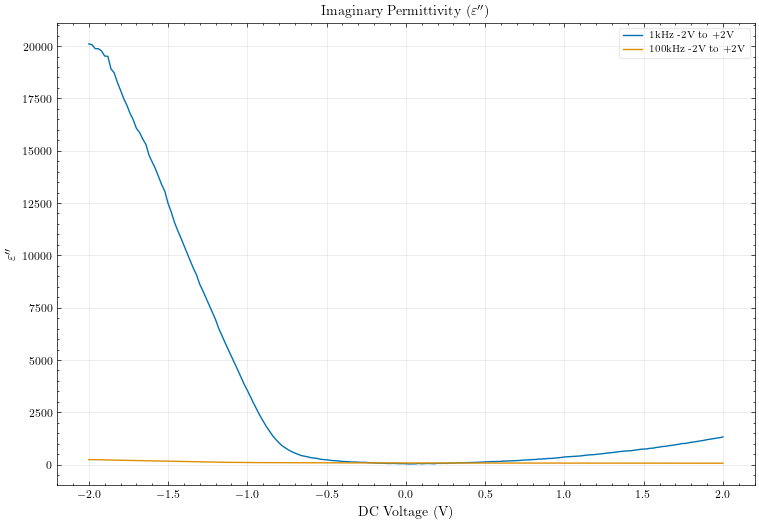

In [16]:
## Permittivity Analysis - MFS097

# Vacuum capacitance C_0 = eps_0 * A / d  (Farads)
# Update these values for your sample geometry:
eps_0 = 8.854e-12       # F/m  (vacuum permittivity)
circ_diameter = 50.0e-6  # m (electrode diameter) — REPLACE with your value
A     = np.pi * (circ_diameter / 2)**2     # m^2  (electrode area) — REPLACE with your value
d     = 30e-9          # m    (film thickness)  — REPLACE with your value
vac_cap = eps_0 * A / d # F
export_data = False 
fig_eps_real, fig_eps_imag = plot_permittivity(
    [smu_MFS097],
    #run_nums = [1],
    vac_cap=vac_cap,
    log_plot=False,
    export_data=export_data,
    output_SMU=output_MFS097,
    fig_name='MFS097',
    plot_transparency=plot_transparency)


In [17]:
smu_MFS097.cv_run_nums

[0, 1]

=== Testing x_lim masking with auto y-scaling ===
1. IV plot with x_lim=[0, 5] - y-axis should auto-scale to data in this range


/Users/horatiocox/Desktop/Thin_Film_Analysis/SMU_functions.py:624: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


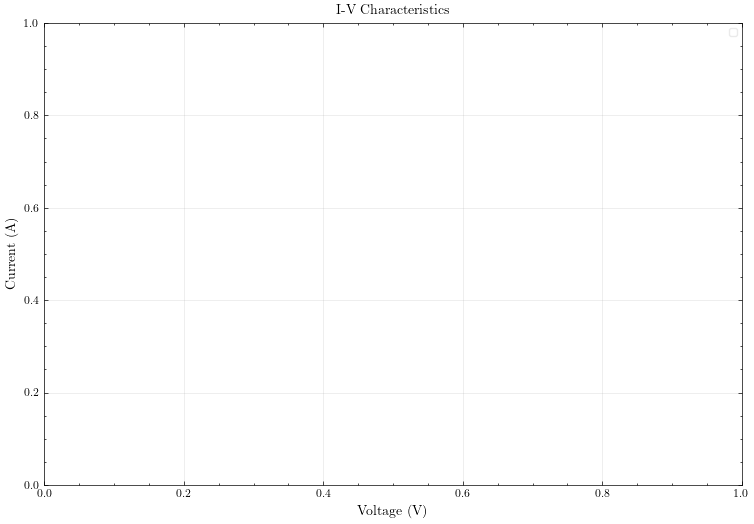

2. Resistance plot with x_lim=[-2, 2] - y-axis should auto-scale to resistance in this range


/Users/horatiocox/Desktop/Thin_Film_Analysis/SMU_functions.py:1803: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


RuntimeError: latex was not able to process the following string:
b'Resistance (\\u03a9)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmppqohy11z dd78dad3b36dfbdfa64d85acce8e5796.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.26 (TeX Live 2024) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./dd78dad3b36dfbdfa64d85acce8e5796.tex
LaTeX2e <2023-11-01> patch level 1
L3 programming layer <2024-02-20>
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/article.cls
Document Class: article 2023/05/17 v1.4n Standard LaTeX document class
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2024/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2024/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2024/texmf

<Figure size 900x600 with 1 Axes>

Now y-axis automatically scales to show only the data within the x_lim range!


In [18]:
## Testing x_lim Data Masking with Auto Y-scaling

print("=== Testing x_lim masking with auto y-scaling ===")

# Test 1: IV plot with x_lim masking (y should auto-scale to visible data)
print("1. IV plot with x_lim=[0, 5] - y-axis should auto-scale to data in this range")
fig_iv_masked = plot_IV([smu_DR012], run_nums=selected_iv_runs, 
                       x_lim=[0, 5],  # Only show 0 to 5V range - y will auto-scale
                       plot_mode='linear', plot_arrows=True,
                       export_data=False, output_SMU=output_SMU)

# Test 2: Resistance plot with x_lim masking
print("2. Resistance plot with x_lim=[-2, 2] - y-axis should auto-scale to resistance in this range")
fig_R_masked = plot_resistance([smu_DR012], run_nums=selected_iv_runs, 
                              x_lim=[-2, 2],  # Focus on -2V to +2V - y will auto-scale
                              log_plot=True, plot_arrows=True,
                              export_data=False, output_SMU=output_SMU)

print("Now y-axis automatically scales to show only the data within the x_lim range!")

### AFM Linescan


AFM data loaded successfully!
Data shape: (498, 12)

Data ranges:
Linescan 1 - X: 0.00 to 4.86 μm, Y: -0.41 to 0.57 nm
Linescan 2 - X: 0.00 to 4.86 μm, Y: -0.36 to 0.41 nm
Linescan 3 - X: 0.00 to 4.86 μm, Y: -0.39 to 0.38 nm


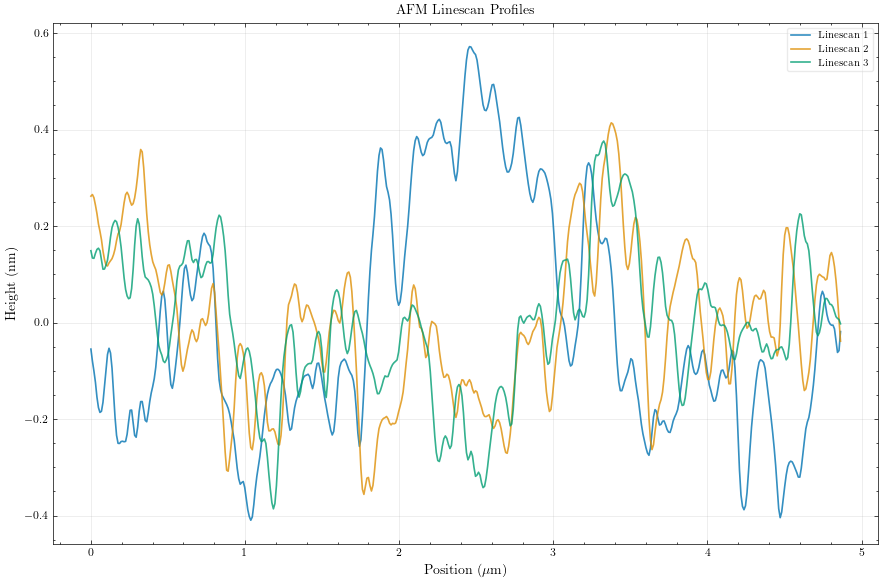


=== AFM Linescan Statistics ===

Linescan 1:
  Mean height: -0.00 nm
  Height std: 0.24 nm
  Peak-to-valley: 0.98 nm
  Scan length: 4.86 μm

Linescan 2:
  Mean height: -0.00 nm
  Height std: 0.16 nm
  Peak-to-valley: 0.77 nm
  Scan length: 4.86 μm

Linescan 3:
  Mean height: -0.00 nm
  Height std: 0.15 nm
  Peak-to-valley: 0.76 nm
  Scan length: 4.86 μm

Overall Statistics (all linescans):
  Mean height: -0.00 nm
  Height std: 0.19 nm
  Global peak-to-valley: 0.98 nm


In [19]:
## AFM Linescan Analysis - Multiple Linescans

# Path to AFM linescan data
path = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/AFM/Cypher/LSO_BSO_8a_tt2/linescan/2'
output_linescan = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/AFM/Cypher/LSO_BSO_8a_tt2/linescan'
fig_format = 'pdf'
try:
    # Import AFM linescan data with all 6 columns
    # Columns 1-2: first linescan (x1, y1)
    # Columns 3-4: second linescan (x2, y2) 
    # Columns 5-6: third linescan (x3, y3)
    import re
    
    # Read all 6 columns
    afm_data = pd.read_csv(path, sep=r'\s+', header=None, 
                          names=['x1_m', 'y1_m', 'x2_m', 'y2_m', 'x3_m', 'y3_m'], 
                          engine='python')
    
    # Ensure all data is numeric and handle any string/mixed data
    for col in afm_data.columns:
        afm_data[col] = pd.to_numeric(afm_data[col], errors='coerce')
    
    # Remove any rows with NaN values
    afm_data = afm_data.dropna()
    
    # Convert from meters to more convenient units for all linescans
    # Linescan 1
    afm_data['x1_um'] = afm_data['x1_m'] * 1e6  # Convert to micrometers
    afm_data['y1_nm'] = afm_data['y1_m'] * 1e9  # Convert to nanometers
    
    # Linescan 2  
    afm_data['x2_um'] = afm_data['x2_m'] * 1e6
    afm_data['y2_nm'] = afm_data['y2_m'] * 1e9
    
    # Linescan 3
    afm_data['x3_um'] = afm_data['x3_m'] * 1e6
    afm_data['y3_nm'] = afm_data['y3_m'] * 1e9
    
    print(f"AFM data loaded successfully!")
    print(f"Data shape: {afm_data.shape}")
    print("\nData ranges:")
    print(f"Linescan 1 - X: {afm_data['x1_um'].min():.2f} to {afm_data['x1_um'].max():.2f} μm, Y: {afm_data['y1_nm'].min():.2f} to {afm_data['y1_nm'].max():.2f} nm")
    print(f"Linescan 2 - X: {afm_data['x2_um'].min():.2f} to {afm_data['x2_um'].max():.2f} μm, Y: {afm_data['y2_nm'].min():.2f} to {afm_data['y2_nm'].max():.2f} nm")
    print(f"Linescan 3 - X: {afm_data['x3_um'].min():.2f} to {afm_data['x3_um'].max():.2f} μm, Y: {afm_data['y3_nm'].min():.2f} to {afm_data['y3_nm'].max():.2f} nm")
    
    # Create AFM linescan plot with all three linescans
    fig, ax = plt.subplots(figsize=(fig_size[0], fig_size[1]))
    
    # Define colors for the three linescans
    colors = ['blue', 'red', 'green']
    labels = ['Linescan 1', 'Linescan 2', 'Linescan 3']
    
    # Plot all three linescans
    ax.plot(afm_data['x1_um'], afm_data['y1_nm'], 
            linewidth=1.2, 
            alpha=0.8 if plot_transparency else 1.0,
            label=labels[0])
    
    ax.plot(afm_data['x2_um'], afm_data['y2_nm'], 
            linewidth=1.2, 
            alpha=0.8 if plot_transparency else 1.0,
            label=labels[1])
    
    ax.plot(afm_data['x3_um'], afm_data['y3_nm'], 
            linewidth=1.2, 
            alpha=0.8 if plot_transparency else 1.0,
            label=labels[2])
    
    # Set labels and title
    ax.set_xlabel(r'Position ($\mu$m)')
    ax.set_ylabel(r'Height (nm)')
    ax.set_title(r'AFM Linescan Profiles')
    
    # Add legend to distinguish the linescans
    ax.legend()
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3)
    
    # Apply plot styling
    plt.tight_layout()
    
    # Export if requested
    if export_data:
        # Create output filename
        output_filename = f"AFM_multiple_linescans.{fig_format}"
        output_path = os.path.join(output_linescan, output_filename)
        
        # Save figure
        fig.savefig(output_path, dpi=600, bbox_inches='tight', 
                   transparent=plot_transparency, format=fig_format)
        print(f"\nAFM plot saved to: {output_path}")
    
    plt.show()
    
    # Display data statistics for all linescans
    print(f"\n=== AFM Linescan Statistics ===")
    
    for i, suffix in enumerate(['1', '2', '3'], 1):
        y_col = f'y{suffix}_nm'
        x_col = f'x{suffix}_um'
        print(f"\nLinescan {i}:")
        print(f"  Mean height: {afm_data[y_col].mean():.2f} nm")
        print(f"  Height std: {afm_data[y_col].std():.2f} nm")
        print(f"  Peak-to-valley: {afm_data[y_col].max() - afm_data[y_col].min():.2f} nm")
        print(f"  Scan length: {afm_data[x_col].max() - afm_data[x_col].min():.2f} μm")
    
    # Overall statistics
    all_heights = pd.concat([afm_data['y1_nm'], afm_data['y2_nm'], afm_data['y3_nm']])
    print(f"\nOverall Statistics (all linescans):")
    print(f"  Mean height: {all_heights.mean():.2f} nm")
    print(f"  Height std: {all_heights.std():.2f} nm")
    print(f"  Global peak-to-valley: {all_heights.max() - all_heights.min():.2f} nm")
    
except FileNotFoundError:
    print(f"Error: Could not find file at {path}")
    print("Please check the file path and try again.")
except Exception as e:
    print(f"Error loading AFM data: {e}")
    print("Please check the file format - expecting 6 columns (x1,y1,x2,y2,x3,y3 in meters)")
    print("\nTrying alternative file reading methods...")
    
    # Alternative reading method
    try:
        with open(path, 'r') as f:
            lines = f.readlines()[:10]  # Show first 10 lines
            print("First few lines of the file:")
            for i, line in enumerate(lines, 1):
                print(f"Line {i}: {repr(line)}")
    except:
        print("Could not read file content for debugging.")

# RHEED Analysis